## Access Station Lucinda Jetty Daily Satlantic-Hyperocr (Zarr)
This Jupyter notebook demonstrates how to access and plot station_lucinda_jetty_daily_satlantic-hyperocr data, available as a [Zarr](https://zarr.dev/) dataset stored on S3.

🔗 More information about the dataset is available [in the AODN metadata catalogue](https://catalogue-imos.aodn.org.au/geonetwork/srv/eng/catalog.search#/metadata/4ac6bf81-cd37-4611-8da8-4d5ae5e2bda3).

📌 The source of truth for this notebook is maintained on [GitHub](https://github.com/aodn/aodn_cloud_optimised/tree/main/notebooks/station_lucinda_jetty_daily_satlantic-hyperocr.ipynb).


In [1]:
dataset_name = "station_lucinda_jetty_daily_satlantic_hyperocr"

## Install/Update packages and Load common functions

In [2]:
import os, requests, importlib.util

open('setup.py', 'w').write(requests.get('https://raw.githubusercontent.com/aodn/aodn_cloud_optimised/main/notebooks/setup.py').text)

spec = importlib.util.spec_from_file_location("setup", "setup.py")
setup = importlib.util.module_from_spec(spec)
spec.loader.exec_module(setup)

setup.install_requirements()
setup.load_dataquery()

✅ Virtual environment already exists, skipping creation.


Using Python 3.12.6 environment at: /home/lbesnard/github_repo/aodn_cloud_optimised/.venv
Resolved 155 packages in 501ms
Checked 155 packages in 2ms


✅ Local version 0.3.13 is up to date (remote: 0.3.13)


In [3]:
from DataQuery import GetAodn

/home/lbesnard/github_repo/aodn_cloud_optimised/notebooks/DataQuery.py:4063: UserWarning: registration of accessor <class 'DataQuery.AODNAccessor'> under name 'aodn' for type <class 'pandas.core.frame.DataFrame'> is overriding a preexisting attribute with the same name.
  @pd.api.extensions.register_dataframe_accessor("aodn")


# Understanding the Dataset

In [4]:
# remote zarr dataset
aodn = GetAodn(bucket_name="imos-data-lab-optimised")
dname = f'{dataset_name}.zarr'
%time aodn_dataset = aodn.get_dataset(dname)

CPU times: user 484 ms, sys: 52.1 ms, total: 537 ms
Wall time: 1.27 s


In [5]:
ds = aodn_dataset.zarr_store
ds.info()

xarray.Dataset {
dimensions:
	WAVELENGTH_Ed = 137 ;
	TIME = 22293 ;

variables:
	float64 Ed(WAVELENGTH_Ed, TIME) ;
		Ed:averaging_period = Regular 5.0 minutes ;
		Ed:cell_methods = TIME: median ;
		Ed:description = The median value of the downwelling spectral sky irradiance taken at a nadir viewing angle of 0 deg measured from the downward vertical axis. ;
		Ed:long_name = Downwelling spectral sky irradiance: median ;
		Ed:units = uW/cm^2/nm ;
	float64 Ed_Total_num_obs(TIME) ;
		Ed_Total_num_obs:description = Total number of observations including invalid data ;
		Ed_Total_num_obs:long_name = Total number of observations ;
		Ed_Total_num_obs:units = 1 ;
	float64 Ed_max(WAVELENGTH_Ed, TIME) ;
		Ed_max:cell_methods = TIME: maximum ;
		Ed_max:description = The maximum of the downwelling spectral sky irradiance taken at a nadir viewing angle of 0 deg measured from the downward vertical axis. ;
		Ed_max:long_name = Downwelling spectral sky irradiance: maximum ;
		Ed_max:units = uW/cm^2/nm ;

## Plot time coverage

In [6]:
aodn_dataset.get_temporal_extent()

(Timestamp('2015-06-25 02:05:00'), Timestamp('2016-12-11 00:05:00'))

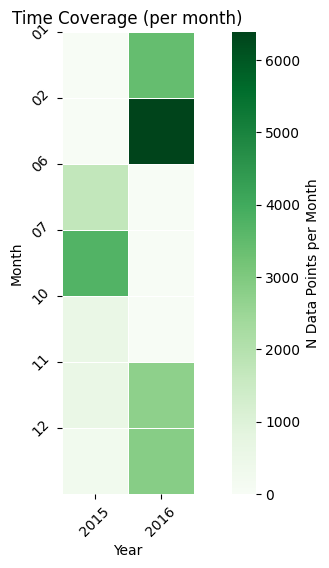

In [7]:
aodn_dataset.plot_time_coverage()

## Load Ed Irradiance Data

Access the Zarr store and load the downwelling spectral irradiance (Ed) dataset.
Ed covers 350–810 nm at ~3.4 nm resolution (137 bands), sampled at ~5-minute intervals.
Units are μW cm⁻² nm⁻¹.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

xds = aodn_dataset.zarr_store

time_vals = xds["TIME"].values
t_min = pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
t_max = pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")
wl = xds["WAVELENGTH_Ed"].values

print(f"Dataset: {xds.dims['TIME']:,} time steps from {t_min} to {t_max}")
print(f"Wavelength range: {wl.min():.0f}–{wl.max():.0f} nm ({len(wl)} bands, ~{np.diff(wl).mean():.1f} nm spacing)")
print(f"Variables: {list(xds.data_vars)}")
print(xds["Ed"])


Dataset: 22,293 time steps from 2015-06-25 to 2016-12-11
Wavelength range: 349–805 nm (137 bands, ~3.4 nm spacing)
Variables: ['Ed', 'Ed_Total_num_obs', 'Ed_max', 'Ed_min', 'Ed_num_obs', 'Ed_sd', 'Ed_spectemp', 'Ed_spectemp_max', 'Ed_spectemp_min', 'Ed_spectemp_num_obs', 'Ed_spectemp_sd', 'filename', 'saa', 'saa_max', 'saa_min', 'saa_num_obs', 'saa_sd', 'sza', 'sza_max', 'sza_min', 'sza_num_obs', 'sza_sd']
<xarray.DataArray 'Ed' (WAVELENGTH_Ed: 137, TIME: 22293)> Size: 24MB
[3054141 values with dtype=float64]
Coordinates:
    LATITUDE       float64 8B ...
    LONGITUDE      float64 8B ...
  * TIME           (TIME) datetime64[ns] 178kB 2015-06-25T02:05:00 ... 2016-1...
  * WAVELENGTH_Ed  (WAVELENGTH_Ed) float32 548B 348.6 352.0 ... 802.0 805.3
Attributes:
    averaging_period:  Regular 5.0 minutes
    cell_methods:      TIME: median
    description:       The median value of the downwelling spectral sky irrad...
    long_name:         Downwelling spectral sky irradiance: median
    unit

## Ed Hyperspectral Signatures

Full 350–810 nm downwelling irradiance spectra at selected dates.
The solar spectrum shows:
- **Near-UV (350–400 nm)**: low energy, but ecologically important — drives CDOM photobleaching and affects coral reef biology on the GBR
- **Visible / PAR (400–700 nm)**: dominant photosynthetically active radiation peak
- **Near-IR (700–810 nm)**: rapidly diminishing irradiance beyond red

Spectra are coloured by acquisition date; each represents the daily median at solar noon conditions.


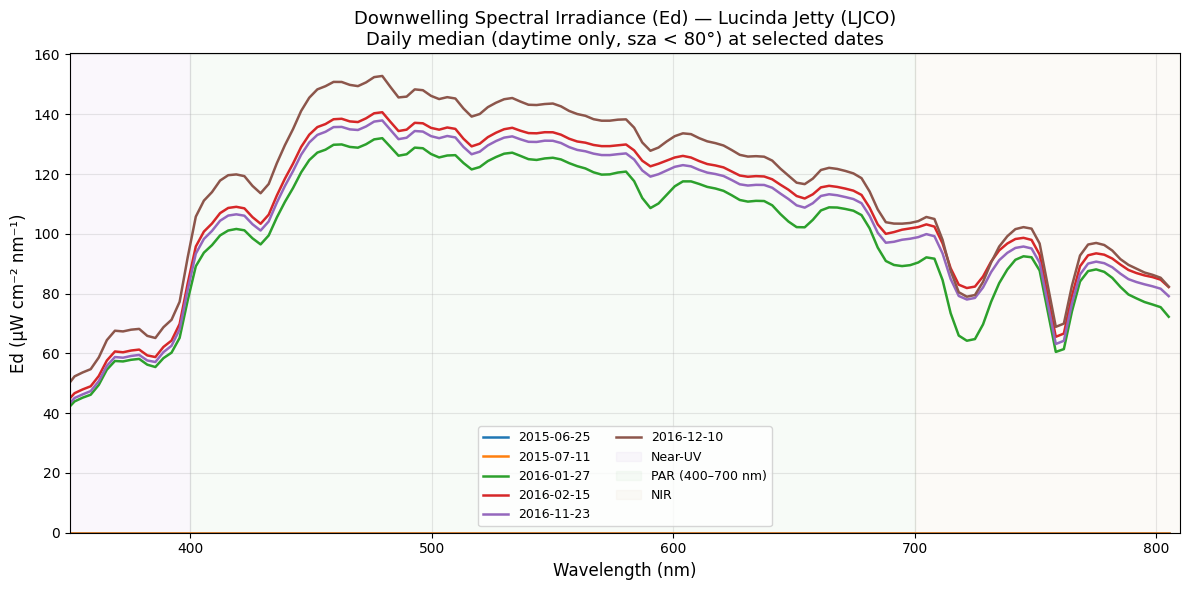

In [9]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl = xds["WAVELENGTH_Ed"].values

# Daily median of Ed and filter to daytime only (sza < 80°)
ed_da  = xds["Ed"].sel(TIME=slice(DATE_START, DATE_END))
sza_da = xds["sza"].sel(TIME=slice(DATE_START, DATE_END))

# Keep only daytime spectra for daily median
ed_day = ed_da.where(sza_da < 80)
ed_daily = ed_day.resample(TIME="1D").median("TIME").astype(float)

# Pick 6 evenly-spaced days with valid data
good_times = ed_daily.TIME.values[
    np.where(~np.all(np.isnan(ed_daily.values), axis=0))[0]
]
n_show = min(6, len(good_times))
pick_idx = np.linspace(0, len(good_times) - 1, n_show, dtype=int)
sample_times = good_times[pick_idx]

fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("tab10")

for i, t in enumerate(sample_times):
    spec = ed_daily.sel(TIME=t, method="nearest").values
    label = pd.Timestamp(t).strftime("%Y-%m-%d")
    ax.plot(wl, spec, color=cmap(i), lw=1.8, label=label)

# Spectral region shading
for xlo, xhi, col, lbl in [
    (350, 400, "#c0a0e0", "Near-UV"),
    (400, 700, "#a0d0a0", "PAR (400–700 nm)"),
    (700, 810, "#e0c0a0", "NIR"),
]:
    ax.axvspan(xlo, xhi, alpha=0.08, color=col, label=lbl)

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Ed (μW cm⁻² nm⁻¹)", fontsize=12)
ax.set_title(
    "Downwelling Spectral Irradiance (Ed) — Lucinda Jetty (LJCO)\n"
    "Daily median (daytime only, sza < 80°) at selected dates",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Ed Hovmöller Diagram

Wavelength–time heatmap of daily median Ed (daytime only).
The tropical seasonal cycle is clearly visible: Australian summer (DJF) brings higher
solar elevations and greater UV–visible irradiance; winter (JJA) shows reduced flux,
especially in the near-UV band.


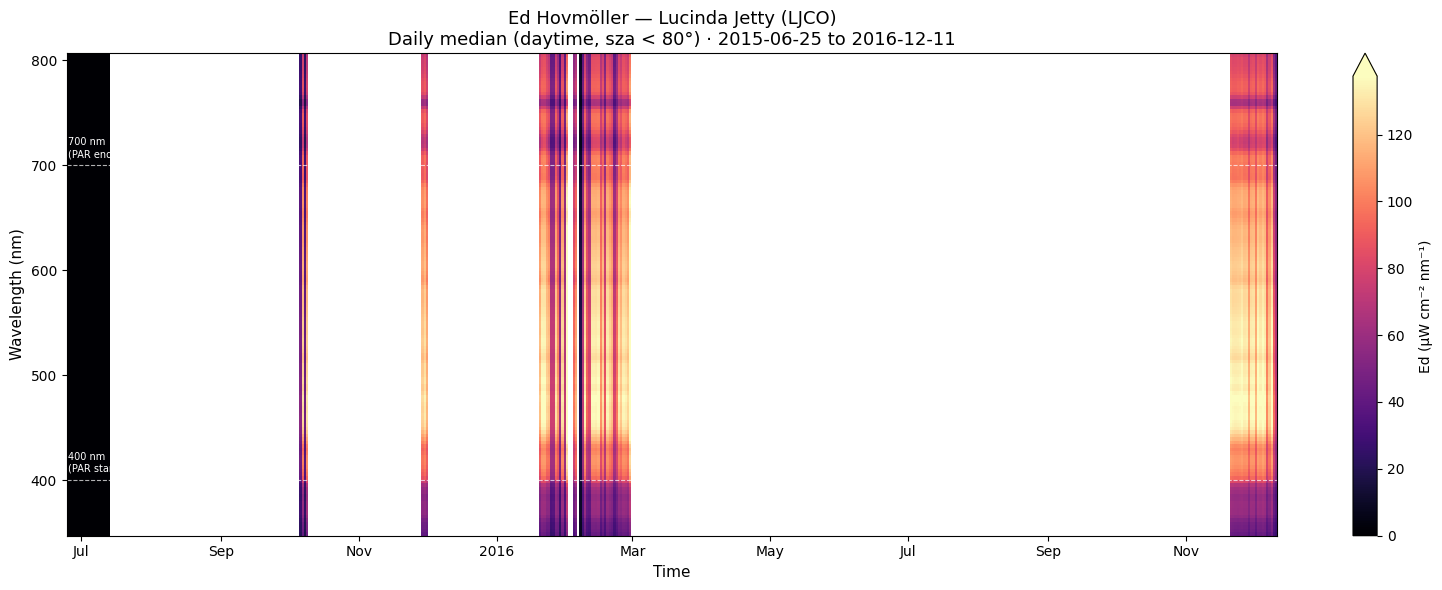

In [10]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl = xds["WAVELENGTH_Ed"].values
ed_da  = xds["Ed"].sel(TIME=slice(DATE_START, DATE_END))
sza_da = xds["sza"].sel(TIME=slice(DATE_START, DATE_END))
ed_day   = ed_da.where(sza_da < 80)
ed_daily = ed_day.resample(TIME="1D").median("TIME").astype(float)

fig, ax = plt.subplots(figsize=(16, 6))
ed_daily.plot(
    x="TIME", y="WAVELENGTH_Ed",
    ax=ax, robust=True,
    cmap="magma",
    cbar_kwargs={"label": "Ed (μW cm⁻² nm⁻¹)"},
)
ax.set_title(
    "Ed Hovmöller — Lucinda Jetty (LJCO)\n"
    f"Daily median (daytime, sza < 80°) · {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlabel("Time", fontsize=11)
ax.set_ylabel("Wavelength (nm)", fontsize=11)

# Mark spectral region boundaries
for wl_mark, lbl, col in [(400, "400 nm\n(PAR start)", "white"),
                           (700, "700 nm\n(PAR end)", "white")]:
    ax.axhline(wl_mark, color=col, lw=0.8, ls="--", alpha=0.7)
    ax.text(pd.Timestamp(DATE_START), wl_mark + 6, lbl,
            color=col, fontsize=7, va="bottom")

plt.tight_layout()
plt.show()


## Ed at Key Wavelengths with Variability Envelope

Daily median Ed at four characteristic wavelengths, with the ±1σ envelope (Ed_sd) shaded.
A wide Ed_sd band indicates high sub-daily variability, typically caused by cloud cover
passing across the sky during the measurement window.

The **coefficient of variation** (CV = Ed_sd / Ed) is a useful cloud-cover proxy:
- CV < 0.1 → clear sky
- CV > 0.3 → overcast / intermittent clouds


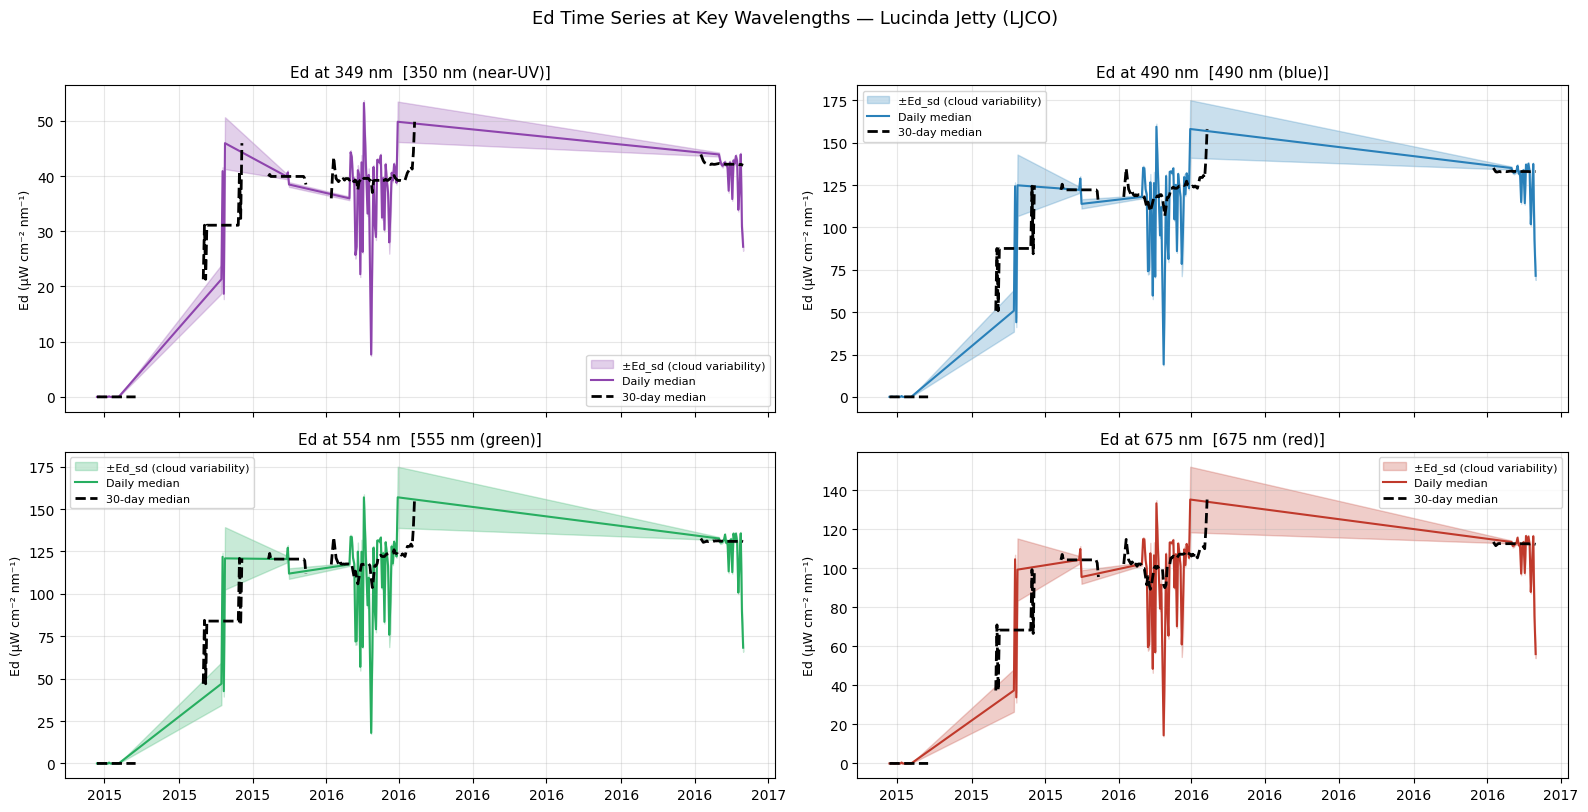

In [11]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

KEY_WL  = {"350 nm (near-UV)": 350, "490 nm (blue)": 490,
           "555 nm (green)": 555, "675 nm (red)": 675}
COLORS  = {"350 nm (near-UV)": "#8e44ad", "490 nm (blue)": "#2980b9",
           "555 nm (green)": "#27ae60", "675 nm (red)": "#c0392b"}

wl_arr = xds["WAVELENGTH_Ed"].values
sub    = xds.sel(TIME=slice(DATE_START, DATE_END))
sza_da = sub["sza"]

ed_day    = sub["Ed"].where(sza_da < 80)
ed_sd_day = sub["Ed_sd"].where(sza_da < 80)
ed_daily    = ed_day.resample(TIME="1D").median("TIME").astype(float)
ed_sd_daily = ed_sd_day.resample(TIME="1D").median("TIME").astype(float)

fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes = axes.flatten()

for ax, (label, target_wl) in zip(axes, KEY_WL.items()):
    idx = int(np.argmin(np.abs(wl_arr - target_wl)))
    actual_wl = wl_arr[idx]
    ed_ts  = ed_daily.isel(WAVELENGTH_Ed=idx).values
    sd_ts  = ed_sd_daily.isel(WAVELENGTH_Ed=idx).values
    t_ts   = pd.to_datetime(ed_daily.TIME.values)

    valid = ~np.isnan(ed_ts)
    color = COLORS[label]
    ax.fill_between(t_ts[valid],
                    (ed_ts - sd_ts)[valid], (ed_ts + sd_ts)[valid],
                    alpha=0.25, color=color, label="±Ed_sd (cloud variability)")
    ax.plot(t_ts[valid], ed_ts[valid], color=color, lw=1.5, label="Daily median")

    # 30-day rolling median
    roll = pd.Series(ed_ts, index=t_ts).rolling("30D", center=True).median()
    ax.plot(roll.index, roll.values, color="k", lw=2, ls="--", label="30-day median")

    ax.set_title(f"Ed at {actual_wl:.0f} nm  [{label}]", fontsize=11)
    ax.set_ylabel("Ed (μW cm⁻² nm⁻¹)", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle(
    "Ed Time Series at Key Wavelengths — Lucinda Jetty (LJCO)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()


## Integrated Radiometry: Near-UV and PAR

Spectrally integrated irradiance over two ecologically important bands:

| Band | Range | Ecological relevance |
|---|---|---|
| **Near-UV** | 350–400 nm | CDOM photobleaching, DNA damage, coral stress |
| **PAR** | 400–700 nm | Photosynthetically active radiation — drives primary production |

The **cloud-cover proxy** (daily-mean coefficient of variation, CV = Ed_sd / Ed)
highlights cloudy periods that suppress both UV and photosynthetic irradiance.
Near the GBR, high UV periods with low cloud cover can be associated with elevated
coral bleaching risk.


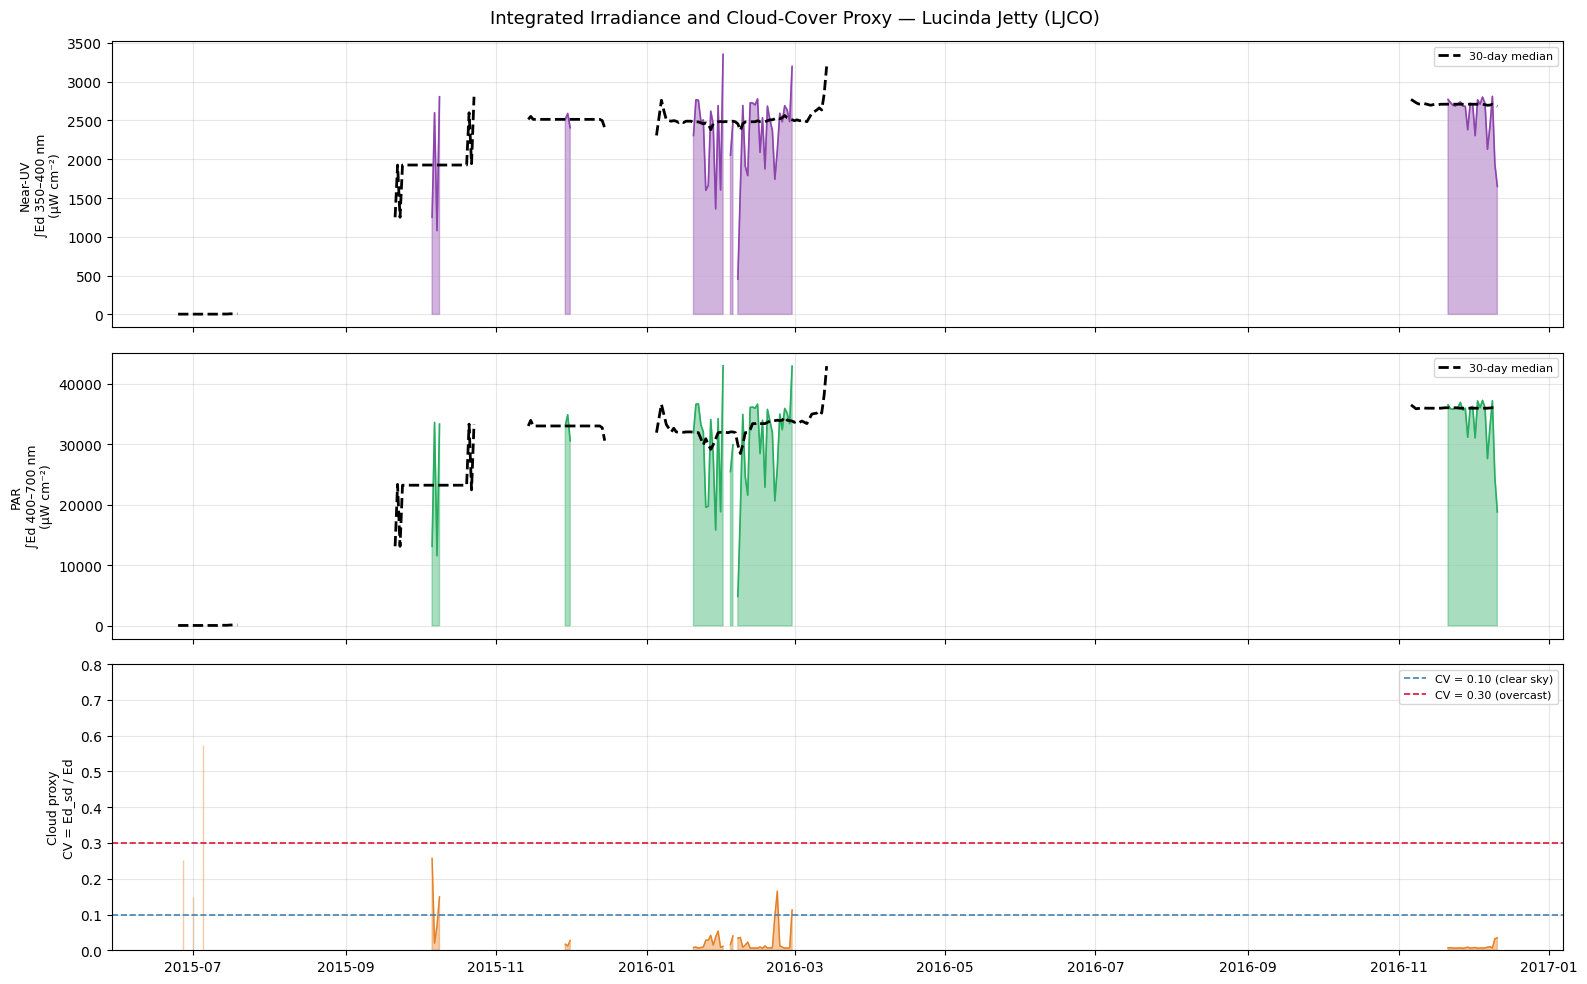

In [12]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH_Ed"].values
sub    = xds.sel(TIME=slice(DATE_START, DATE_END))
sza_da = sub["sza"]

ed_day    = sub["Ed"].where(sza_da < 80).astype(float)
ed_sd_day = sub["Ed_sd"].where(sza_da < 80).astype(float)
ed_daily    = ed_day.resample(TIME="1D").median("TIME")
ed_sd_daily = ed_sd_day.resample(TIME="1D").median("TIME")

t_daily = pd.to_datetime(ed_daily.TIME.values)
ed_np   = ed_daily.values        # (WAVELENGTH_Ed, TIME)
ed_sd_np = ed_sd_daily.values

# Spectral masks
uv_mask  = (wl_arr >= 350) & (wl_arr < 400)
par_mask = (wl_arr >= 400) & (wl_arr <= 700)

# Integrate over wavelength (trapz along axis=0 = WAVELENGTH_Ed)
uv_int  = np.trapz(ed_np[uv_mask,  :], wl_arr[uv_mask],  axis=0)
par_int = np.trapz(ed_np[par_mask, :], wl_arr[par_mask], axis=0)

# Cloud proxy: spectral-mean CV
with np.errstate(invalid="ignore", divide="ignore"):
    cv = np.nanmean(
        np.where(ed_np > 0.1, ed_sd_np / ed_np, np.nan),
        axis=0,
    )
uv_int  = np.where(uv_int  > 0, uv_int,  np.nan)
par_int = np.where(par_int > 0, par_int, np.nan)
cv      = np.where(cv > 0, cv, np.nan)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Near-UV integral
ax1.fill_between(t_daily, uv_int, alpha=0.4, color="#8e44ad")
ax1.plot(t_daily, uv_int, color="#8e44ad", lw=1.2)
roll_uv = pd.Series(uv_int, index=t_daily).rolling("30D", center=True).median()
ax1.plot(roll_uv.index, roll_uv.values, color="k", lw=2, ls="--", label="30-day median")
ax1.set_ylabel("Near-UV\n∫Ed 350–400 nm\n(μW cm⁻²)", fontsize=9)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# PAR integral
ax2.fill_between(t_daily, par_int, alpha=0.4, color="#27ae60")
ax2.plot(t_daily, par_int, color="#27ae60", lw=1.2)
roll_par = pd.Series(par_int, index=t_daily).rolling("30D", center=True).median()
ax2.plot(roll_par.index, roll_par.values, color="k", lw=2, ls="--", label="30-day median")
ax2.set_ylabel("PAR\n∫Ed 400–700 nm\n(μW cm⁻²)", fontsize=9)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# Cloud proxy (CV)
ax3.fill_between(t_daily, cv, alpha=0.4, color="#e67e22")
ax3.plot(t_daily, cv, color="#e67e22", lw=1.0)
ax3.axhline(0.1, color="steelblue", ls="--", lw=1.2, label="CV = 0.10 (clear sky)")
ax3.axhline(0.3, color="crimson",   ls="--", lw=1.2, label="CV = 0.30 (overcast)")
ax3.set_ylabel("Cloud proxy\nCV = Ed_sd / Ed", fontsize=9)
ax3.set_ylim(0, 0.8)
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

fig.suptitle(
    "Integrated Irradiance and Cloud-Cover Proxy — Lucinda Jetty (LJCO)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


## Seasonal Mean Ed Spectra

Mean (±1σ) Ed spectra grouped by austral season, daytime only (sza < 80°):
- **DJF** (Dec–Feb) — tropical wet season: highest solar angle at this latitude; strong UV and PAR
- **MAM** (Mar–May) — transition period
- **JJA** (Jun–Aug) — austral winter: lowest solar elevation, reduced irradiance
- **SON** (Sep–Nov) — spring: increasing solar elevation and irradiance

The seasonal amplitude in UV irradiance is relevant for estimating
annual CDOM photobleaching rates in coastal GBR waters.


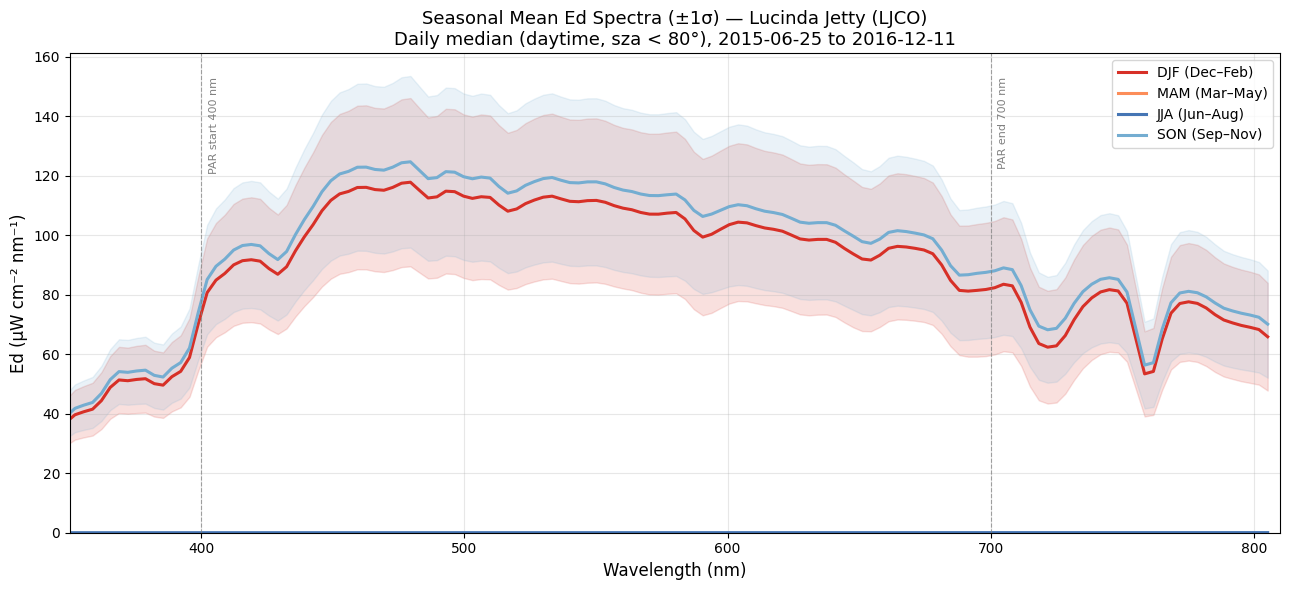

In [13]:
DATE_START = ""
DATE_END   = ""
time_vals = xds["TIME"].values
DATE_START = DATE_START or pd.Timestamp(time_vals[0]).strftime("%Y-%m-%d")
DATE_END   = DATE_END   or pd.Timestamp(time_vals[-1]).strftime("%Y-%m-%d")

wl_arr = xds["WAVELENGTH_Ed"].values
ed_da  = xds["Ed"].sel(TIME=slice(DATE_START, DATE_END))
sza_da = xds["sza"].sel(TIME=slice(DATE_START, DATE_END))
ed_day   = ed_da.where(sza_da < 80)
ed_daily = ed_day.resample(TIME="1D").median("TIME").astype(float)

months  = pd.to_datetime(ed_daily.TIME.values).month
ed_np   = ed_daily.values  # (WAVELENGTH_Ed, TIME)

seasons = {
    "DJF (Dec–Feb)": ([12, 1, 2],  "#d73027"),
    "MAM (Mar–May)": ([3, 4, 5],   "#fc8d59"),
    "JJA (Jun–Aug)": ([6, 7, 8],   "#4575b4"),
    "SON (Sep–Nov)": ([9, 10, 11], "#74add1"),
}

fig, ax = plt.subplots(figsize=(13, 6))

for season, (month_list, color) in seasons.items():
    mask = np.isin(months, month_list)
    if mask.sum() == 0:
        continue
    s_data = ed_np[:, mask]
    mean_s = np.nanmean(s_data, axis=1)
    std_s  = np.nanstd(s_data,  axis=1)
    ax.plot(wl_arr, mean_s, color=color, lw=2.2, label=season)
    ax.fill_between(wl_arr, mean_s - std_s, mean_s + std_s,
                    color=color, alpha=0.15)

# Mark spectral region boundaries
for xb, lbl in [(400, "PAR start 400 nm"), (700, "PAR end 700 nm")]:
    ax.axvline(xb, color="grey", lw=0.8, ls="--", alpha=0.7)
    ax.text(xb + 3, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 140,
            lbl, rotation=90, fontsize=8, color="grey", va="top")

ax.set_xlabel("Wavelength (nm)", fontsize=12)
ax.set_ylabel("Ed (μW cm⁻² nm⁻¹)", fontsize=12)
ax.set_title(
    "Seasonal Mean Ed Spectra (±1σ) — Lucinda Jetty (LJCO)\n"
    f"Daily median (daytime, sza < 80°), {DATE_START} to {DATE_END}",
    fontsize=13,
)
ax.set_xlim(350, 810)
ax.set_ylim(bottom=0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
